(np.float64(0.0), np.float64(2.0), np.float64(0.0), np.float64(15.0))

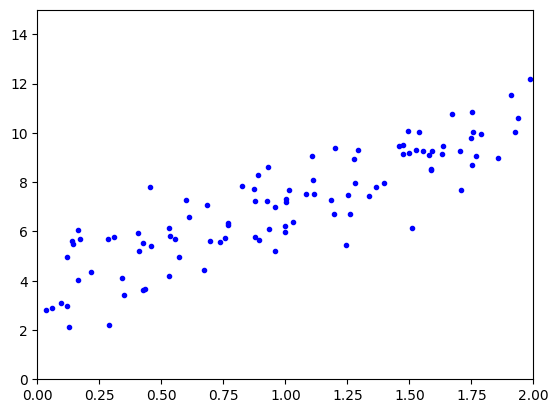

In [34]:
import numpy as np
import matplotlib.pyplot as plt


x=2 *np.random.rand(100 ,1)
y= 4 + 3* x +np.random.randn(100,1)

plt.plot(x,y,"b.")
plt.axis([0,2,0,15])


In [15]:
x_b = np.c_[np.ones((100,1)) ,x]
theta_best = np.linalg.inv(x_b.T.dot(x_b)).dot(x_b.T).dot(y)
theta_best

array([[4.23165171],
       [2.79048742]])

In [24]:
X_new = np.array([[0], [2]])
X_new_b = np.c_[np.ones((2, 1)), X_new]
y_predict = X_new_b.dot(theta_best)
y_predict

array([[4.23165171],
       [9.81262655]])

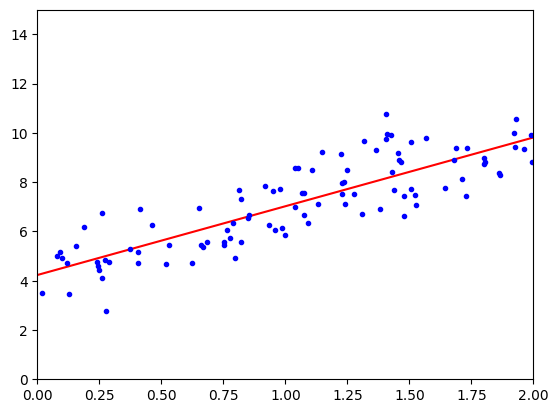

In [29]:
plt.plot(X_new, y_predict, "r-")
plt.plot(x, y, "b.")
plt.axis([0, 2, 0, 15])
plt.show()

In [ ]:
eta = 0.1
n_iterations = 1000
m =100 
theta= np.random.randn(2,1)
for iteration in range(n_iterations):
    gradients = 2/m * x_b.T.dot(x_b.dot(theta) - y)
    theta = theta - eta * gradients





array([[6.3970024],
       [0.6506894]])

In [61]:
n_epochs = 50 
t0 , t1 = 5 ,50 


def learning_schedule(t):
    return t0 /(t + t1)

theta_path_mgd = []
theta= np.random.randn(2,1)
for epoch in range(n_epochs):
    for i in range(m):
        random_index = np.random.randint(m)
        xi = x_b[random_index:random_index+1]
        yi = y[random_index:random_index+1]
        gradients = 2 * xi.T.dot(xi.dot(theta) - yi)
        eta = learning_schedule(epoch * m + i)
        theta = theta - eta * gradients


In [44]:
from sklearn.linear_model import SGDRegressor
sgd_regression = SGDRegressor(max_iter=1000 , tol= 1e-3 , penalty=None , eta0=0.1 )
sgd_regression.fit(x, y.ravel())

,loss,'squared_error'
,penalty,None
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,1000
,tol,0.001
,shuffle,True
,verbose,0
,epsilon,0.1
,random_state,None


In [45]:
sgd_regression.intercept_

array([3.61293293])

In [48]:
m = 100
X = 6 * np.random.rand(m, 1) - 3
y = 0.5 * X**2 + X + 2 + np.random.randn(m, 1)


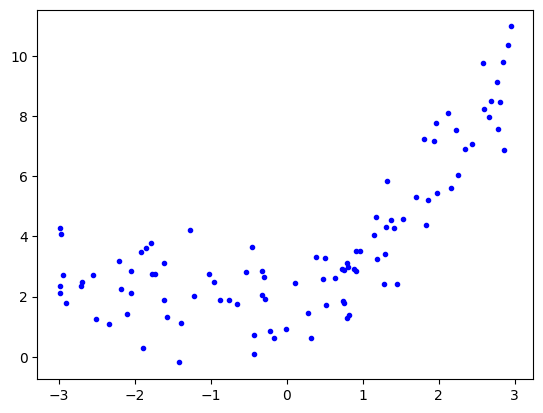

In [49]:
plt.plot(X, y ,"b.")

In [50]:
from sklearn.preprocessing import PolynomialFeatures
poly_features = PolynomialFeatures(degree=2 , include_bias=False)
X_poly = poly_features.fit_transform(X)

In [55]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(X_poly, y)
y_predict = lin_reg.predict(X_poly)
lin_reg.intercept_, lin_reg.coef_

(array([1.98902552]), array([[1.01339593, 0.50408662]]))

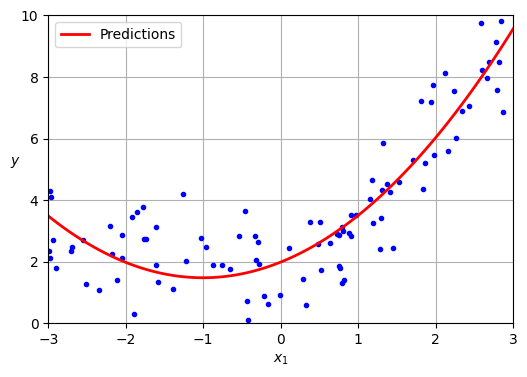

In [62]:
X_new = np.linspace(-3, 3, 100).reshape(100, 1)
X_new_poly = poly_features.transform(X_new)
y_new = lin_reg.predict(X_new_poly)

plt.figure(figsize=(6, 4))
plt.plot(X, y, "b.")
plt.plot(X_new, y_new, "r-", linewidth=2, label="Predictions")
plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.legend(loc="upper left")
plt.axis([-3, 3, 0, 10])
plt.grid()

plt.show()